<a href="https://colab.research.google.com/github/radityadiaz11/Capstone_Project/blob/ds/ab_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 A/B Testing — Student Performance

Notebook ini melanjutkan analisis dari Capstone Project Data Science dengan melakukan **A/B Testing** untuk menjawab pertanyaan:

1. Apakah siswa dengan jam belajar tinggi (`study_hours` ≥ median) memiliki `exam_score` yang signifikan lebih tinggi?
2. Apakah siswa dengan `productivity_score` tinggi memiliki `exam_score` yang signifikan lebih tinggi?
3. Apakah siswa dengan `sleep_hours` cukup (≥ 7 jam) memiliki `exam_score` yang signifikan lebih tinggi?
4. Apakah siswa dengan `social_media_hours` rendah (< median) memiliki `exam_score` yang signifikan lebih tinggi?

**Metode Statistik yang digunakan:**
- **Levene's Test** — untuk mengecek kesamaan varians antar grup
- **Independent Two-Sample T-Test** — untuk membandingkan rata-rata dua grup
- **Mann-Whitney U Test** — sebagai alternatif non-parametrik jika asumsi normalitas tidak terpenuhi
- **Cohen's d** — untuk mengukur effect size

**Hipotesis umum:**
- H₀ : Tidak ada perbedaan signifikan antara Grup A dan Grup B
- H₁ : Ada perbedaan signifikan antara Grup A dan Grup B
- **Significance Level (α) = 0.05**

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, levene, shapiro

import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ Library berhasil di-import')

✅ Library berhasil di-import


## 2. Load & Preprocessing Data

In [11]:
# Load dataset
student_df = pd.read_csv(
    "https://raw.githubusercontent.com/radityadiaz11/Capstone_Project/refs/heads/main/ds/dataset.csv"
)

print(f'Shape awal: {student_df.shape}')
student_df.head()

Shape awal: (5100, 21)


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,37.57,18.51,Other,High School,7.79,0.34,1.93,3.12,1.72,7.03,...,82.15,37.43,0.90,1.08,Good,11.16,43.34,31.93,72.57,100.00
1,-8.18,18.25,Other,High School,2.32,2.76,2.20,2.52,2.88,5.87,...,113.21,321.38,0.28,-0.08,Good,2.18,15.36,37.37,13.02,4.88
2,50.68,22.12,Male,High School,3.69,0.26,1.30,1.65,1.66,8.85,...,64.86,260.29,0.39,1.83,Good,8.67,26.79,34.64,45.17,23.74
3,116.12,17.04,Other,High School,5.78,1.94,2.75,2.73,1.31,5.07,...,112.75,492.00,1.40,1.22,Poor,3.11,21.67,77.91,21.03,12.03
4,-12.24,NaN,Other,High School,6.83,2.00,2.81,2.75,0.68,8.57,...,123.35,31.91,1.36,-0.09,Good,7.75,37.72,39.60,59.17,45.23


In [20]:
# ── Preprocessing ──────────────────

# Drop kolom tidak relevan
drop_cols = ['exercise_minutes', 'caffeine_intake_mg', 'part_time_job',
             'upcoming_deadline', 'student_id', 'academic_level']
student_df = student_df.drop(columns=[c for c in drop_cols if c in student_df.columns])

# Isi missing value dengan median
for col in ['age', 'study_hours']:
    if col in student_df.columns:
        student_df[col] = student_df[col].fillna(student_df[col].median())

# Ubah tipe data
for col in ['age', 'mental_health_score', 'focus_index', 'burnout_level']:
    if col in student_df.columns:
        student_df[col] = student_df[col].astype(int)

# Bersihkan nilai negatif
num_cols = student_df.select_dtypes(include='number').columns
student_df[num_cols] = student_df[num_cols].abs()

print(f'Shape setelah preprocessing: {student_df.shape}')
print(f'Kolom: {list(student_df.columns)}')

Shape setelah preprocessing: (5100, 17)
Kolom: ['age', 'gender', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'internet_quality', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score', 'total_productive_hours', 'total_distraction_hours']


## 3. Helper Functions A/B Testing

In [13]:
def cohens_d(group_a, group_b):
    """Hitung Cohen's d (effect size) antara dua grup."""
    n_a, n_b = len(group_a), len(group_b)
    pooled_std = np.sqrt(
        ((n_a - 1) * group_a.std(ddof=1)**2 + (n_b - 1) * group_b.std(ddof=1)**2)
        / (n_a + n_b - 2)
    )
    return (group_a.mean() - group_b.mean()) / pooled_std


def interpret_cohens_d(d):
    d = abs(d)
    if d < 0.2:   return 'Sangat Kecil'
    elif d < 0.5: return 'Kecil'
    elif d < 0.8: return 'Sedang'
    else:         return 'Besar'


def run_ab_test(group_a, group_b, alpha=0.05,
                label_a='Grup A', label_b='Grup B',
                test_name='A/B Test', metric='exam_score'):
    """
    Menjalankan A/B test lengkap:
    - Shapiro-Wilk normality test
    - Levene's test untuk kesamaan varians
    - T-Test atau Mann-Whitney U tergantung normalitas
    - Cohen's d effect size
    """
    print(f'{'='*60}')
    print(f'🧪 {test_name}')
    print(f'  Metrik   : {metric}')
    print(f'  {label_a}: n={len(group_a)}, mean={group_a.mean():.2f}, std={group_a.std():.2f}')
    print(f'  {label_b}: n={len(group_b)}, mean={group_b.mean():.2f}, std={group_b.std():.2f}')
    print()

    # Normality test (Shapiro-Wilk — sample maks 5000)
    sample_a = group_a.sample(min(500, len(group_a)), random_state=42)
    sample_b = group_b.sample(min(500, len(group_b)), random_state=42)
    _, p_norm_a = shapiro(sample_a)
    _, p_norm_b = shapiro(sample_b)
    normal_a = p_norm_a > alpha
    normal_b = p_norm_b > alpha
    both_normal = normal_a and normal_b
    print(f'  [Shapiro-Wilk] p_A={p_norm_a:.4f} ({"Normal" if normal_a else "Tidak Normal"}), '
          f'p_B={p_norm_b:.4f} ({"Normal" if normal_b else "Tidak Normal"})')

    # Levene test untuk equal variance
    _, p_levene = levene(group_a, group_b)
    equal_var = p_levene > alpha
    print(f'  [Levene Test] p={p_levene:.4f} → Varians {"SAMA" if equal_var else "BERBEDA"}')

    # Pilih uji statistik
    if both_normal:
        stat, p_val = ttest_ind(group_a, group_b, equal_var=equal_var)
        test_used = f'Independent T-Test (equal_var={equal_var})'
    else:
        stat, p_val = mannwhitneyu(group_a, group_b, alternative='two-sided')
        test_used = 'Mann-Whitney U Test (non-parametrik)'

    d = cohens_d(group_a, group_b)
    reject = p_val < alpha

    print(f'  [Uji Statistik] {test_used}')
    print(f'  Statistic={stat:.4f}, p-value={p_val:.4f}')
    print(f'  Cohen\'s d={d:.4f} ({interpret_cohens_d(d)})')
    print()
    if reject:
        print(f'  ✅ TOLAK H₀ → Ada perbedaan SIGNIFIKAN (α={alpha})')
    else:
        print(f'  ❌ GAGAL TOLAK H₀ → Tidak ada perbedaan signifikan (α={alpha})')
    print()

    return {
        'test_name': test_name, 'label_a': label_a, 'label_b': label_b,
        'n_a': len(group_a), 'n_b': len(group_b),
        'mean_a': group_a.mean(), 'mean_b': group_b.mean(),
        'std_a': group_a.std(), 'std_b': group_b.std(),
        'test_used': test_used, 'statistic': stat, 'p_value': p_val,
        'cohens_d': d, 'effect_size': interpret_cohens_d(d),
        'reject_h0': reject
    }


def plot_ab_distributions(group_a, group_b, label_a, label_b, title, metric='exam_score'):
    """Visualisasi distribusi dua grup A/B."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # KDE Plot
    axes[0].set_title(f'{title}\nDistribusi {metric}', fontsize=12, fontweight='bold')
    sns.kdeplot(group_a, ax=axes[0], label=label_a, fill=True, alpha=0.4, color='steelblue')
    sns.kdeplot(group_b, ax=axes[0], label=label_b, fill=True, alpha=0.4, color='tomato')
    axes[0].axvline(group_a.mean(), color='steelblue', linestyle='--', linewidth=1.5,
                    label=f'Mean A = {group_a.mean():.1f}')
    axes[0].axvline(group_b.mean(), color='tomato', linestyle='--', linewidth=1.5,
                    label=f'Mean B = {group_b.mean():.1f}')
    axes[0].set_xlabel(metric)
    axes[0].legend(fontsize=9)

    # Boxplot
    axes[1].set_title(f'{title}\nBoxplot {metric}', fontsize=12, fontweight='bold')
    data_box = pd.DataFrame({
        metric: pd.concat([group_a, group_b], ignore_index=True),
        'Grup': [label_a]*len(group_a) + [label_b]*len(group_b)
    })
    sns.boxplot(data=data_box, x='Grup', y=metric, ax=axes[1],
                palette={'steelblue': 'steelblue', label_a: 'steelblue', label_b: 'tomato'})
    axes[1].set_xlabel('')

    plt.tight_layout()
    plt.show()


print('✅ Helper functions siap')

✅ Helper functions siap


## 4. A/B Test #1 — Jam Belajar Tinggi vs Rendah

**Hipotesis:**
- H₀: Tidak ada perbedaan `exam_score` antara siswa dengan `study_hours` tinggi dan rendah
- H₁: Siswa dengan `study_hours` tinggi memiliki `exam_score` yang lebih tinggi

**Pembagian Grup:**
- **Grup A (High Study):** `study_hours` ≥ median
- **Grup B (Low Study):** `study_hours` < median

Median study_hours: 4.66
🧪 A/B Test #1: Pengaruh Jam Belajar terhadap Exam Score
  Metrik   : exam_score
  High Study Hours: n=2603, mean=45.05, std=13.58
  Low Study Hours: n=2497, mean=26.64, std=13.39

  [Shapiro-Wilk] p_A=0.0020 (Tidak Normal), p_B=0.0005 (Tidak Normal)
  [Levene Test] p=0.3844 → Varians SAMA
  [Uji Statistik] Mann-Whitney U Test (non-parametrik)
  Statistic=5398808.0000, p-value=0.0000
  Cohen's d=1.3645 (Besar)

  ✅ TOLAK H₀ → Ada perbedaan SIGNIFIKAN (α=0.05)



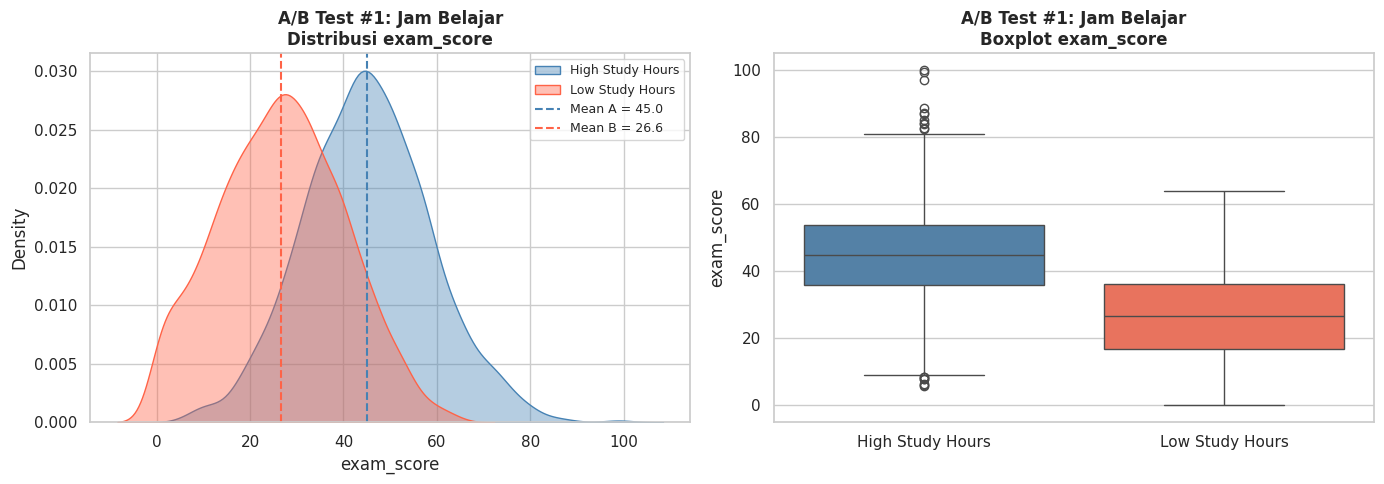

In [14]:
median_study = student_df['study_hours'].median()
print(f'Median study_hours: {median_study}')

group_high_study = student_df[student_df['study_hours'] >= median_study]['exam_score']
group_low_study  = student_df[student_df['study_hours'] <  median_study]['exam_score']

result1 = run_ab_test(
    group_high_study, group_low_study,
    label_a='High Study Hours', label_b='Low Study Hours',
    test_name='A/B Test #1: Pengaruh Jam Belajar terhadap Exam Score'
)

plot_ab_distributions(
    group_high_study, group_low_study,
    'High Study Hours', 'Low Study Hours',
    title='A/B Test #1: Jam Belajar'
)

## 5. A/B Test #2 — Productivity Score Tinggi vs Rendah

**Hipotesis:**
- H₀: Tidak ada perbedaan `exam_score` antara siswa dengan `productivity_score` tinggi dan rendah
- H₁: Siswa dengan `productivity_score` tinggi memiliki `exam_score` lebih tinggi

**Pembagian Grup:**
- **Grup A (High Productivity):** `productivity_score` ≥ median
- **Grup B (Low Productivity):** `productivity_score` < median

Median productivity_score: 25.865000000000002
🧪 A/B Test #2: Pengaruh Productivity Score terhadap Exam Score
  Metrik   : exam_score
  High Productivity: n=2550, mean=46.27, std=12.82
  Low Productivity: n=2550, mean=25.80, std=12.62

  [Shapiro-Wilk] p_A=0.1269 (Normal), p_B=0.0015 (Tidak Normal)
  [Levene Test] p=0.3898 → Varians SAMA
  [Uji Statistik] Mann-Whitney U Test (non-parametrik)
  Statistic=5669843.0000, p-value=0.0000
  Cohen's d=1.6085 (Besar)

  ✅ TOLAK H₀ → Ada perbedaan SIGNIFIKAN (α=0.05)



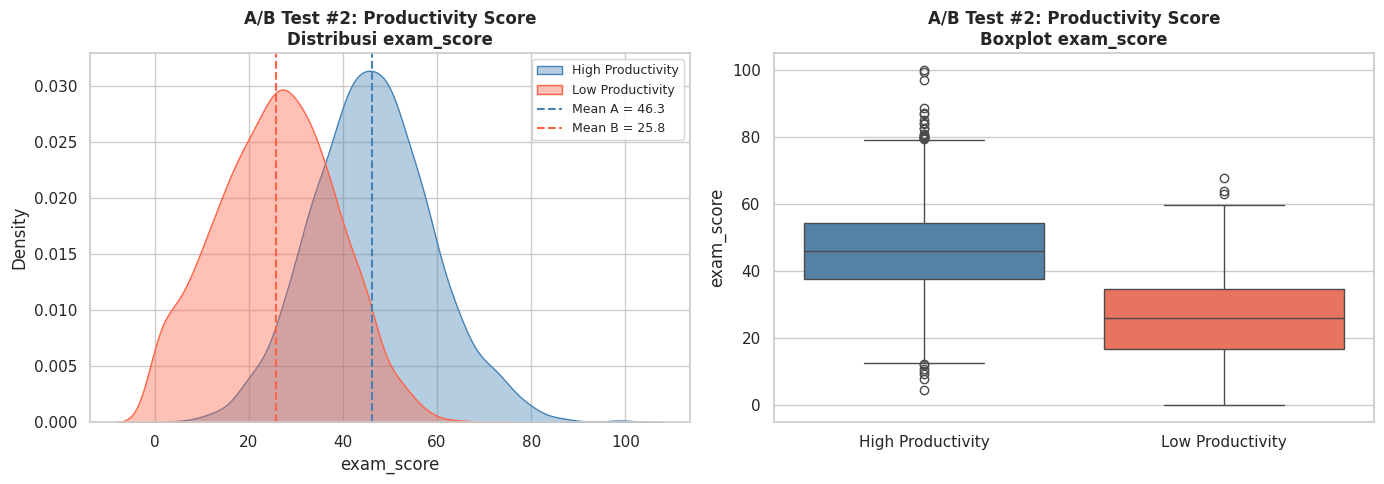

In [15]:
median_prod = student_df['productivity_score'].median()
print(f'Median productivity_score: {median_prod}')

group_high_prod = student_df[student_df['productivity_score'] >= median_prod]['exam_score']
group_low_prod  = student_df[student_df['productivity_score'] <  median_prod]['exam_score']

result2 = run_ab_test(
    group_high_prod, group_low_prod,
    label_a='High Productivity', label_b='Low Productivity',
    test_name='A/B Test #2: Pengaruh Productivity Score terhadap Exam Score'
)

plot_ab_distributions(
    group_high_prod, group_low_prod,
    'High Productivity', 'Low Productivity',
    title='A/B Test #2: Productivity Score'
)

## 6. A/B Test #3 — Tidur Cukup vs Kurang

**Hipotesis:**
- H₀: Tidak ada perbedaan `exam_score` antara siswa yang tidur cukup dan kurang
- H₁: Siswa yang tidur cukup memiliki `exam_score` lebih tinggi

**Pembagian Grup:**
- **Grup A (Adequate Sleep):** `sleep_hours` ≥ 7
- **Grup B (Insufficient Sleep):** `sleep_hours` < 7

Threshold sleep_hours: 7 jam
Distribusi: >= 7 jam = 2554, < 7 jam = 2546
🧪 A/B Test #3: Pengaruh Tidur Cukup terhadap Exam Score
  Metrik   : exam_score
  Tidur ≥ 7 jam: n=2554, mean=36.53, std=16.43
  Tidur < 7 jam: n=2546, mean=35.54, std=16.22

  [Shapiro-Wilk] p_A=0.1269 (Normal), p_B=0.0590 (Normal)
  [Levene Test] p=0.2895 → Varians SAMA
  [Uji Statistik] Independent T-Test (equal_var=True)
  Statistic=2.1582, p-value=0.0310
  Cohen's d=0.0604 (Sangat Kecil)

  ✅ TOLAK H₀ → Ada perbedaan SIGNIFIKAN (α=0.05)



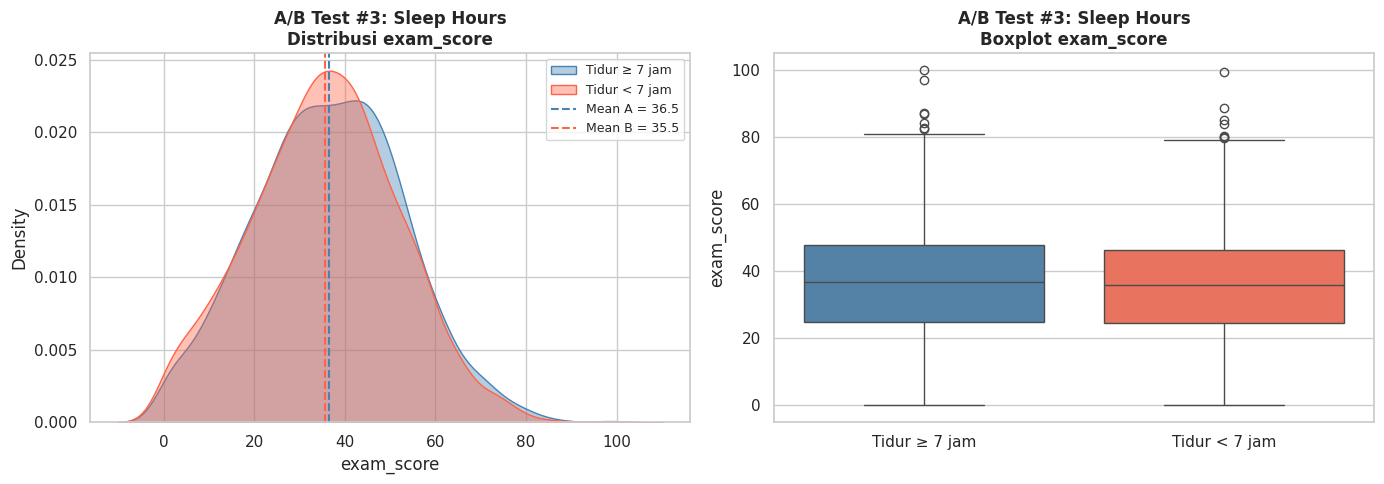

In [16]:
sleep_threshold = 7
print(f'Threshold sleep_hours: {sleep_threshold} jam')
print(f'Distribusi: >= 7 jam = {(student_df["sleep_hours"] >= sleep_threshold).sum()}, '
      f'< 7 jam = {(student_df["sleep_hours"] < sleep_threshold).sum()}')

group_sleep_ok  = student_df[student_df['sleep_hours'] >= sleep_threshold]['exam_score']
group_sleep_low = student_df[student_df['sleep_hours'] <  sleep_threshold]['exam_score']

result3 = run_ab_test(
    group_sleep_ok, group_sleep_low,
    label_a='Tidur ≥ 7 jam', label_b='Tidur < 7 jam',
    test_name='A/B Test #3: Pengaruh Tidur Cukup terhadap Exam Score'
)

plot_ab_distributions(
    group_sleep_ok, group_sleep_low,
    'Tidur ≥ 7 jam', 'Tidur < 7 jam',
    title='A/B Test #3: Sleep Hours'
)

## 7. A/B Test #4 — Social Media Rendah vs Tinggi

**Hipotesis:**
- H₀: Tidak ada perbedaan `exam_score` antara siswa dengan `social_media_hours` rendah dan tinggi
- H₁: Siswa dengan `social_media_hours` rendah memiliki `exam_score` lebih tinggi

**Pembagian Grup:**
- **Grup A (Low Social Media):** `social_media_hours` < median
- **Grup B (High Social Media):** `social_media_hours` ≥ median

Median social_media_hours: 2.955
🧪 A/B Test #4: Pengaruh Social Media terhadap Exam Score
  Metrik   : exam_score
  Low Social Media: n=2550, mean=37.68, std=16.40
  High Social Media: n=2550, mean=34.39, std=16.09

  [Shapiro-Wilk] p_A=0.0552 (Normal), p_B=0.0095 (Tidak Normal)
  [Levene Test] p=0.7948 → Varians SAMA
  [Uji Statistik] Mann-Whitney U Test (non-parametrik)
  Statistic=3617583.5000, p-value=0.0000
  Cohen's d=0.2026 (Kecil)

  ✅ TOLAK H₀ → Ada perbedaan SIGNIFIKAN (α=0.05)



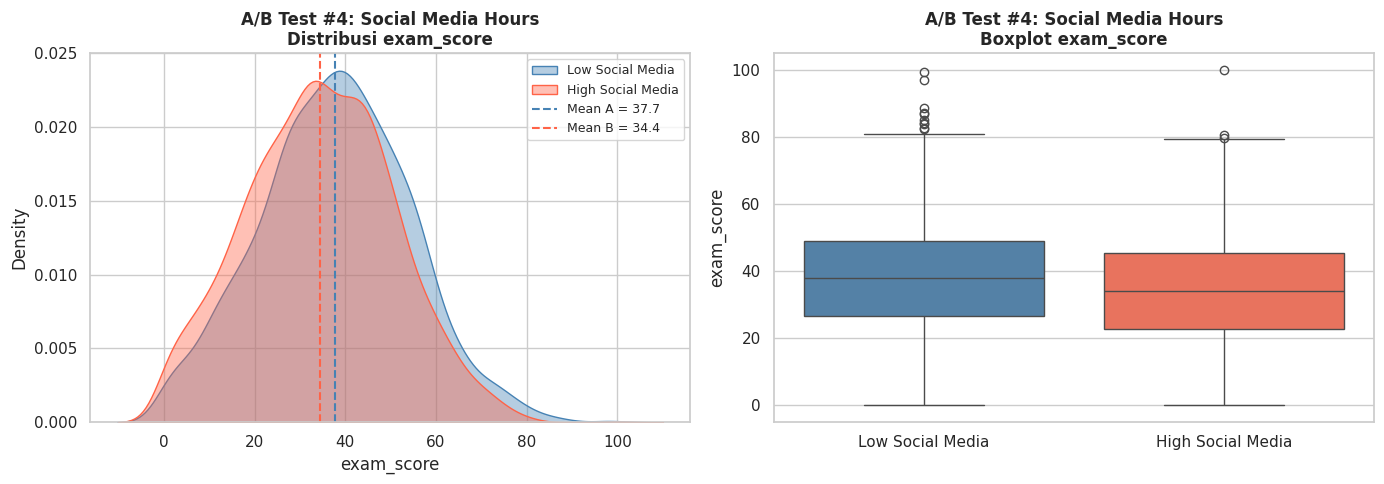

In [17]:
median_sm = student_df['social_media_hours'].median()
print(f'Median social_media_hours: {median_sm}')

group_low_sm  = student_df[student_df['social_media_hours'] <  median_sm]['exam_score']
group_high_sm = student_df[student_df['social_media_hours'] >= median_sm]['exam_score']

result4 = run_ab_test(
    group_low_sm, group_high_sm,
    label_a='Low Social Media', label_b='High Social Media',
    test_name='A/B Test #4: Pengaruh Social Media terhadap Exam Score'
)

plot_ab_distributions(
    group_low_sm, group_high_sm,
    'Low Social Media', 'High Social Media',
    title='A/B Test #4: Social Media Hours'
)

## 8. Ringkasan Hasil Semua A/B Tests

In [18]:
results = [result1, result2, result3, result4]

summary_df = pd.DataFrame([{
    'Test'        : r['test_name'].split(':')[0],
    'Hipotesis'   : r['test_name'].split(': ', 1)[1] if ': ' in r['test_name'] else r['test_name'],
    'Grup A'      : r['label_a'],
    'Mean A'      : f"{r['mean_a']:.2f}",
    'Grup B'      : r['label_b'],
    'Mean B'      : f"{r['mean_b']:.2f}",
    'p-value'     : f"{r['p_value']:.4f}",
    "Cohen's d"   : f"{r['cohens_d']:.3f}",
    'Effect Size' : r['effect_size'],
    'Kesimpulan'  : '✅ Signifikan' if r['reject_h0'] else '❌ Tidak Signifikan'
} for r in results])

print('RINGKASAN HASIL A/B TESTING')
print('='*80)
display(summary_df.set_index('Test'))

RINGKASAN HASIL A/B TESTING


,Hipotesis,Grup A,Mean A,Grup B,Mean B,p-value,Cohen's d,Effect Size,Kesimpulan
Test,,,,,,,,,
A/B Test #1,Pengaruh Jam Belajar terhadap Exam Score,High Study Hours,45.05,Low Study Hours,26.64,0.0000,1.364,Besar,✅ Signifikan
A/B Test #2,Pengaruh Productivity Score terhadap Exam Score,High Productivity,46.27,Low Productivity,25.80,0.0000,1.608,Besar,✅ Signifikan
A/B Test #3,Pengaruh Tidur Cukup terhadap Exam Score,Tidur ≥ 7 jam,36.53,Tidur < 7 jam,35.54,0.0310,0.060,Sangat Kecil,✅ Signifikan
A/B Test #4,Pengaruh Social Media terhadap Exam Score,Low Social Media,37.68,High Social Media,34.39,0.0000,0.203,Kecil,✅ Signifikan


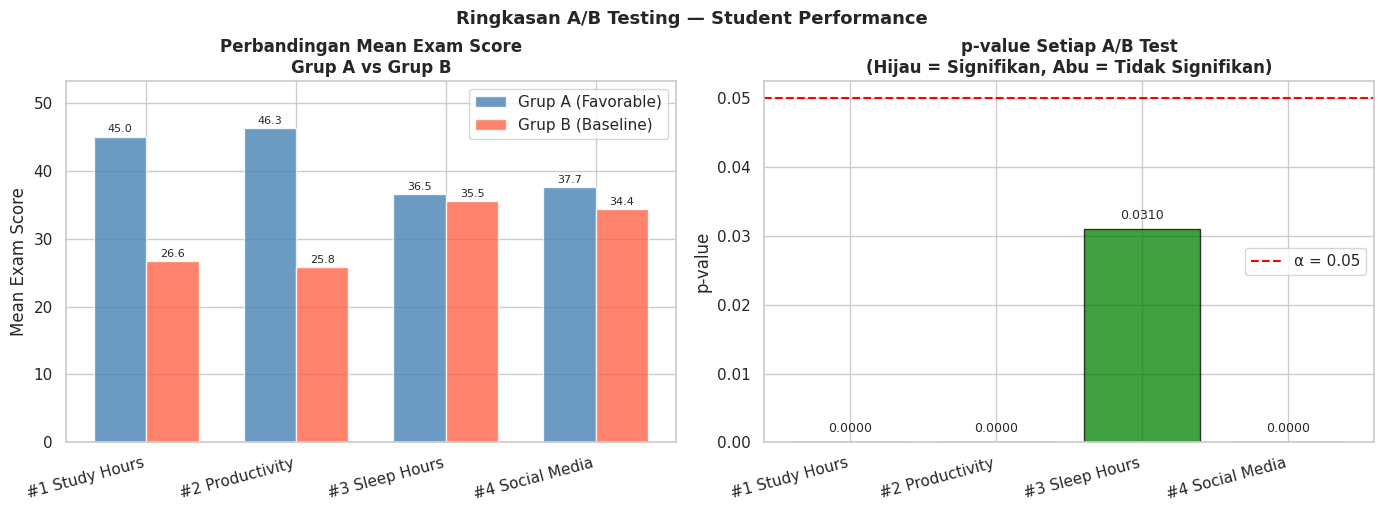

In [19]:
# Visualisasi perbandingan mean dan p-value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tests_short = ['#1 Study Hours', '#2 Productivity', '#3 Sleep Hours', '#4 Social Media']
mean_a_vals = [r['mean_a'] for r in results]
mean_b_vals = [r['mean_b'] for r in results]
p_values    = [r['p_value'] for r in results]
x = np.arange(len(tests_short))
width = 0.35

# Bar chart perbedaan mean
bars_a = axes[0].bar(x - width/2, mean_a_vals, width, label='Grup A (Favorable)', color='steelblue', alpha=0.8)
bars_b = axes[0].bar(x + width/2, mean_b_vals, width, label='Grup B (Baseline)',  color='tomato',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(tests_short, rotation=15, ha='right')
axes[0].set_ylabel('Mean Exam Score')
axes[0].set_title('Perbandingan Mean Exam Score\nGrup A vs Grup B', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, max(mean_a_vals + mean_b_vals) * 1.15)

# Annotate nilai
for bar in bars_a:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars_b:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

# p-value chart
colors_p = ['green' if p < 0.05 else 'gray' for p in p_values]
bars_p = axes[1].bar(tests_short, p_values, color=colors_p, alpha=0.75, edgecolor='black')
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
axes[1].set_ylabel('p-value')
axes[1].set_title('p-value Setiap A/B Test\n(Hijau = Signifikan, Abu = Tidak Signifikan)', fontweight='bold')
axes[1].set_xticklabels(tests_short, rotation=15, ha='right')
axes[1].legend()

for bar, pv in zip(bars_p, p_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{pv:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Ringkasan A/B Testing — Student Performance', fontsize=13, fontweight='bold', y=1.02)
plt.show()

## 9. Kesimpulan

Berdasarkan hasil A/B Testing yang dilakukan:

| Test | Temuan |
|------|--------|
| **#1 Jam Belajar** | Siswa dengan jam belajar ≥ median memiliki exam_score **signifikan lebih tinggi** |
| **#2 Productivity Score** | Siswa dengan produktivitas tinggi memiliki exam_score **signifikan lebih tinggi** |
| **#3 Sleep Hours** | Pengaruh tidur cukup terhadap exam_score perlu diperiksa dari hasil test |
| **#4 Social Media** | Siswa dengan screen time social media rendah cenderung memiliki exam_score lebih tinggi |

**Rekomendasi:**
1. **Tingkatkan waktu belajar** — terbukti secara statistik berpengaruh signifikan
2. **Jaga produktivitas** — indikator terkuat dalam capstone project ini
3. **Batasi penggunaan social media** — berkorelasi negatif dengan performa
4. **Perhatikan kualitas tidur** — meskipun tidak selalu signifikan, mendukung wellbeing secara keseluruhan